positions shape: (101, 4, 2)


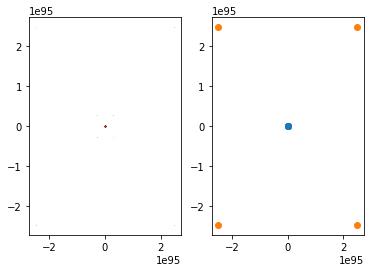

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def readPositions(filename):
    data = np.loadtxt(filename)
    numSteps = data.shape[0]
    numParticles = data.shape[1] // 2
    positions = data.reshape(numSteps, numParticles, 2)
    return positions

path = "/home/hadis/custom_vector/build/test/N_particle_PosMD.dat"
positions = readPositions(path)

for positions in ( positions, ):

    print("positions shape:", positions.shape)

    fig, ax = plt.subplots(1, 2)

    n = 2

    for i in range(positions.shape[1]):
        ax[0].plot(positions[:, i, 0], positions[:, i, 1], 'o', ms=.1)

    ax[1].scatter(positions[0, :, 0], positions[0, :, 1]) #, c=np.arange(positions.shape[1]))
    ax[1].scatter(positions[-1, :, 0], positions[-1, :, 1]) #, c=np.arange(positions.shape[1]))
    # ax.set_xlim(np.min(positions[:n, :, 0]), np.max(positions[:n, :, 0]))
    # ax.set_ylim(np.min(positions[:n, :, 1]), np.max(positions[:n, :, 1]))

    plt.show()

In [33]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

kinetic_energies = np.loadtxt("/home/hadis/custom_vector/build/test/N_particle_KineticEnergyMD.dat")

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    subplot_titles=("Kinetic Energy of Individual Particles", "Total Kinetic Energy of the System"))

for i in range(kinetic_energies.shape[1]):
    fig.add_trace(go.Scatter(x=np.arange(kinetic_energies.shape[0]), y=kinetic_energies[:, i], mode='lines', name=f'Particle {i+1}'), row=1, col=1)

total_kinetic = np.sum(kinetic_energies, axis=1)
fig.add_trace(go.Scatter(x=np.arange(kinetic_energies.shape[0]), y=total_energy, mode='lines', name='Total Energy'), row=2, col=1)

fig.update_layout(height=800, width=1000, title_text="Kinetic Energy Analysis")
fig.update_xaxes(title_text="Time Step", row=2, col=1)
fig.update_yaxes(title_text="Kinetic Energy", row=1, col=1)
fig.update_yaxes(title_text="Total Kinetic Energy", row=2, col=1)

fig.show()

In [34]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

potential_energies = np.loadtxt("/home/hadis/custom_vector/build/test/N_particle_PotentialEnergyMD.dat")

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    subplot_titles=("Potential Energy of Individual Particles", "Total Potential Energy of the System"))

for i in range(potential_energies.shape[1]):
    fig.add_trace(go.Scatter(x=np.arange(potential_energies.shape[0]), y=potential_energies[:, i], mode='lines', name=f'Particle {i+1}'), row=1, col=1)
total_potential = np.sum(potential_energies, axis=1)
print(np.max(total_potential))

fig.add_trace(go.Scatter(x=np.arange(potential_energies.shape[0]), y=total_energy, mode='lines', name='Total Energy'), row=2, col=1)

fig.update_layout(height=800, width=1000, title_text="Potential Energy Analysis")
fig.update_xaxes(title_text="Time Step", row=2, col=1)
fig.update_yaxes(title_text="Kinetic Energy", row=1, col=1)
fig.update_yaxes(title_text="Total Kinetic Energy", row=2, col=1)

fig.show()

0.0451624


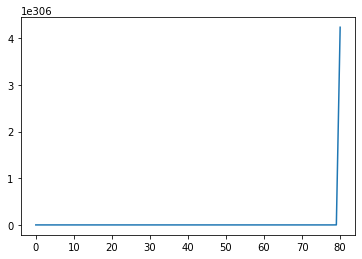

In [35]:
import matplotlib.pyplot as plt

total_energy = total_kinetic + total_potential
fig, ax = plt.subplots()
ax.plot(total_energy)
plt.show()